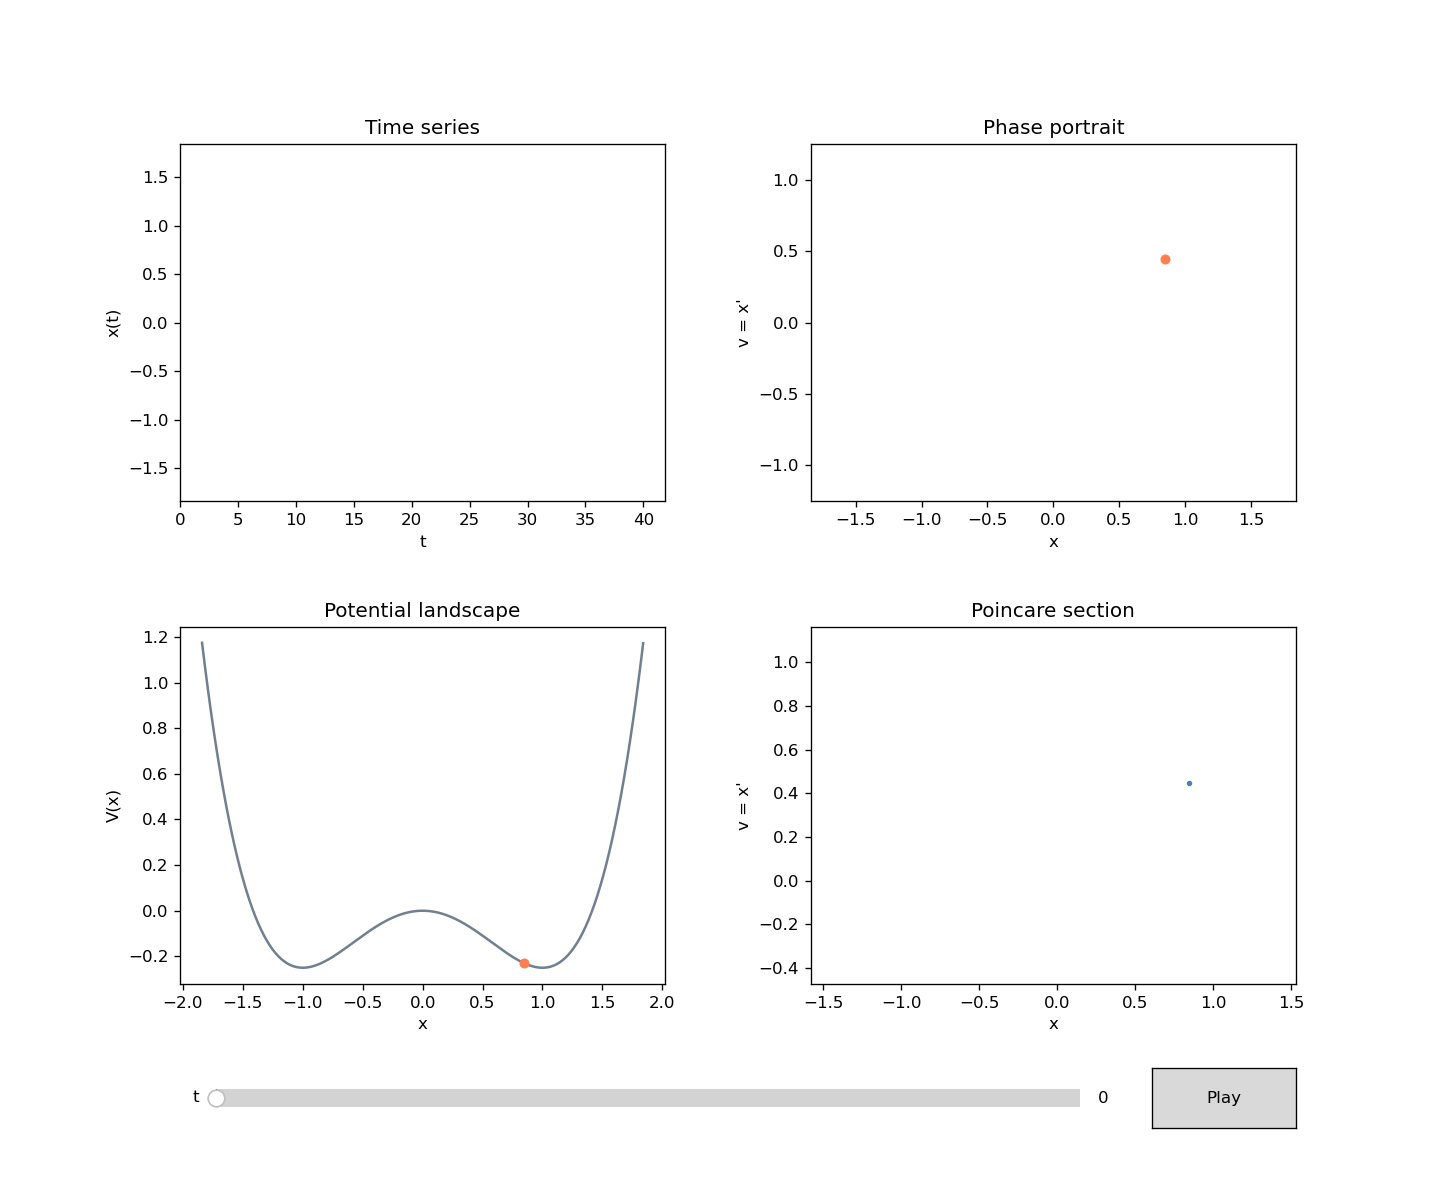

In [1]:
#PREAMBLE

#Duffing equation:
#x'' + delta*x' + alpha*x + beta*x**3 = gamma*cos(omega*t)

#before running:
# pip install numpy scipy matplotlib

#when running:
# A window opens with four panels: x vs t, v vs x, V(x) vs x, and the Poincare section
# the slider can be used to scroll through time, or you can do it automatically with the play button

#IMPORTS

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

#this allows it to run in a notebook cell
%matplotlib widget

#PARAMETERS

#duffing equation values
delta = 0.3 #damping
alpha = -1.0 #stiffness
beta = 1.0 #non-linearity of the restoring force
gamma = 0.5 #amplitude of the periodic driving force
omega = 1.2 #angular velocity

#initial values
x0, v0 = 0.5, 0.0

#determining t
n_periods = 120
n_points_per_period = 60
period = 2 * np.pi / omega
t_max = n_periods * period
dt = period / n_points_per_period
t_eval = np.arange(0, t_max, dt)

#customisation parameters
N_FRAMES = 30000 #number of frames kept
TIME_WINDOW = 8 * period #time window for x(t) vs t
TRAIL = 500 #how long the trail stays

#SOLVING

#restructure so solve_ipv can use it
def duffing(t, state):
    x, v = state
    dxdt = v
    dvdt = gamma*np.cos(omega*t)-delta*v-alpha*x-beta*x**3
    return [dxdt, dvdt]

#solve (numerical integration)
sol = solve_ivp(duffing, [0, t_max], [x0, v0], t_eval = t_eval, method = "RK45", rtol = 1e-9, atol = 1e-9)
t, x, v = sol.t, sol.y[0], sol.y[1]

#discard some periods at the start, so the initial condition is forgotten
skip = 20*n_points_per_period
t, x, v = t[skip:], x[skip:], v[skip:]
t = t-t[0]

#subsample down to a manageable number of animation frames
stride = max(1, len(t)//N_FRAMES)
t_f, x_f, v_f = t[::stride], x[::stride], v[::stride]
n_frames = len(t_f)

#calculate potential energy
def V(xx):
    return 0.5*alpha*xx**2+0.25*beta*xx**4

#make V(x)
x_curve = np.linspace(np.min(x)*1.2, np.max(x)*1.2, 300)
V_curve = V(x_curve)

#poincare section: one point per drive period
period_steps = n_points_per_period
x_poin = x[::period_steps]
v_poin = v[::period_steps]
t_poin = t[::period_steps]

#FIGURES

#setup
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi = 120)
plt.subplots_adjust(bottom=0.18, hspace=0.35, wspace=0.3)
ax_t, ax_phase, ax_pot, ax_poin = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

#x(t) vs t
ax_t.set_xlim(0, TIME_WINDOW)
ax_t.set_ylim(np.min(x)*1.2, np.max(x)*1.2)
ax_t.set_xlabel("t")
ax_t.set_ylabel("x(t)")
ax_t.set_title("Time series")
line_t, = ax_t.plot([], [], color="seagreen", lw=1.5)

#phase portrait (v vs x)
ax_phase.set_xlim(np.min(x)*1.2, np.max(x)*1.2)
ax_phase.set_ylim(np.min(v)*1.2, np.max(v)*1.2)
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("v = x'")
ax_phase.set_title("Phase portrait")
line_phase, = ax_phase.plot([], [], color="steelblue", lw=1)
point_phase, = ax_phase.plot([], [], "o", color="coral", markersize=5)

#potential landscape (V(x) vs x)
ax_pot.plot(x_curve, V_curve, color="slategray", lw=1.5)
ax_pot.set_xlabel("x")
ax_pot.set_ylabel("V(x)")
ax_pot.set_title("Potential landscape")
trail_pot, = ax_pot.plot([], [], color="coral", lw=1, alpha=0.5)
point_pot, = ax_pot.plot([], [], "o", color="coral", markersize=5)

#poincare section (samples one point v vs x per drive period)
ax_poin.set_xlim(np.min(x_poin)*1.2, np.max(x_poin)*1.2)
ax_poin.set_ylim(np.min(v_poin)*1.2, np.max(v_poin)*1.2)
ax_poin.set_xlabel("x")
ax_poin.set_ylabel("v = x'")
ax_poin.set_title("Poincare section")
scat_poin = ax_poin.scatter([], [], s=5, color="steelblue")

#ANIMATION

def draw_frame(idx):
    now = t_f[idx]

    lo_t = np.searchsorted(t_f[:idx+1], max(0, now - TIME_WINDOW))
    line_t.set_data(t_f[lo_t:idx+1], x_f[lo_t:idx+1])
    if now > TIME_WINDOW:
        ax_t.set_xlim(now - TIME_WINDOW, now)

    lo_p = max(0, idx - TRAIL)
    line_phase.set_data(x_f[lo_p:idx+1], v_f[lo_p:idx+1])
    point_phase.set_data([x_f[idx]], [v_f[idx]])

    trail_pot.set_data(x_f[lo_p:idx+1], V(x_f[lo_p:idx+1]))
    point_pot.set_data([x_f[idx]], [V(x_f[idx])])

    poin_n = np.searchsorted(t_poin, now, side="right")
    scat_poin.set_offsets(np.column_stack([x_poin[:poin_n], v_poin[:poin_n]]))

    fig.canvas.draw_idle()

#SLIDER

ax_slider = plt.axes([0.15, 0.07, 0.6, 0.03])
slider = Slider(ax_slider, "t", 0, n_frames - 1, valinit=0, valstep=1)

def on_slider_change(val):
    draw_frame(int(slider.val))

slider.on_changed(on_slider_change)

#PLAY/PAUSE BUTTON

ax_button = plt.axes([0.8, 0.06, 0.1, 0.05])
button = Button(ax_button, "Play")

playing = {"on": False} #initially off
timer = fig.canvas.new_timer(interval=50) #ms between frames

def advance(*_):
    if not playing["on"]:
        return
    next_val = slider.val + 1
    if next_val > n_frames - 1:
        next_val = 0 #loop back to the start
    slider.set_val(next_val) #draw a frame

timer.add_callback(advance)
timer.start()

def toggle_play(event):
    playing["on"] = not playing["on"]
    button.label.set_text("Pause" if playing["on"] else "Play")

button.on_clicked(toggle_play)

draw_frame(0)
plt.show()

Directe formule voor de amplitude over de tijd

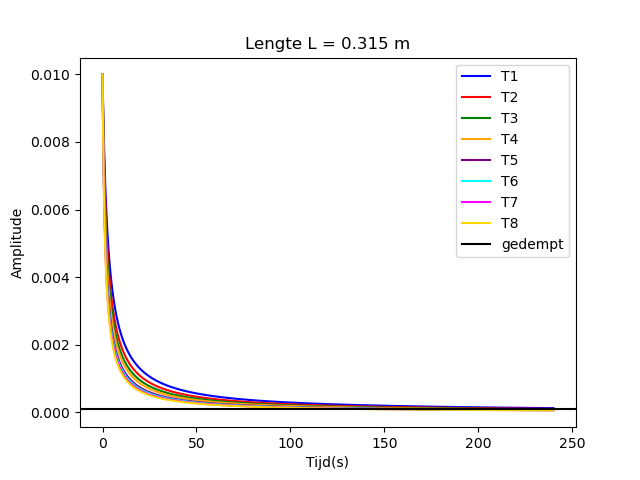

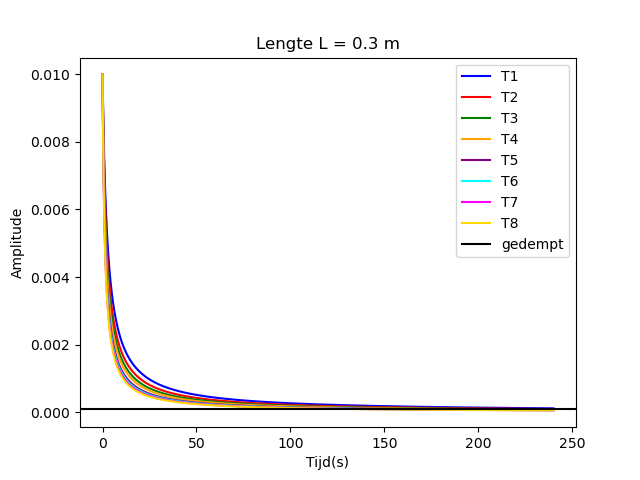

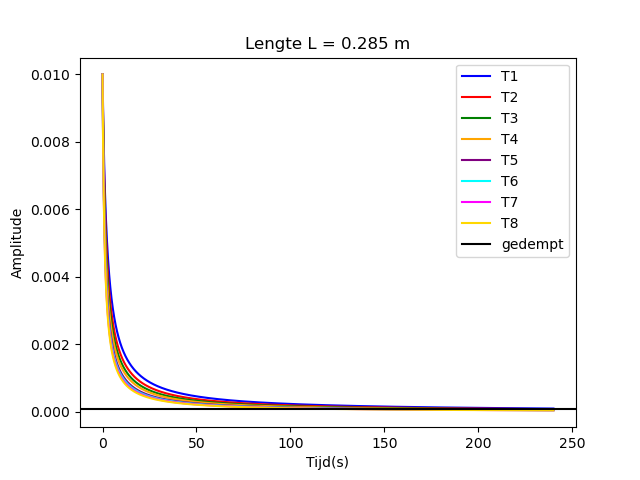

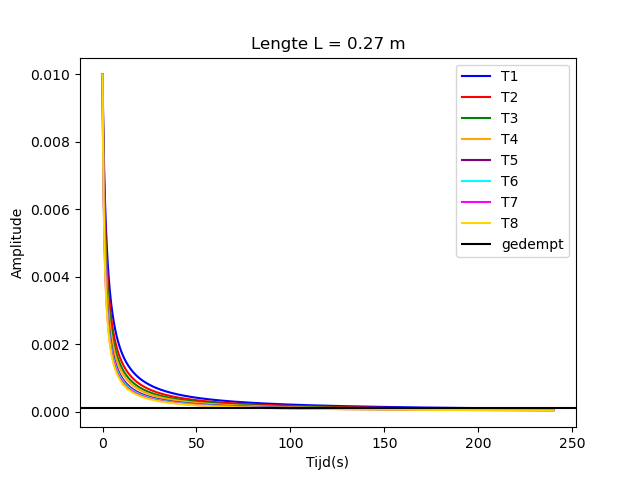

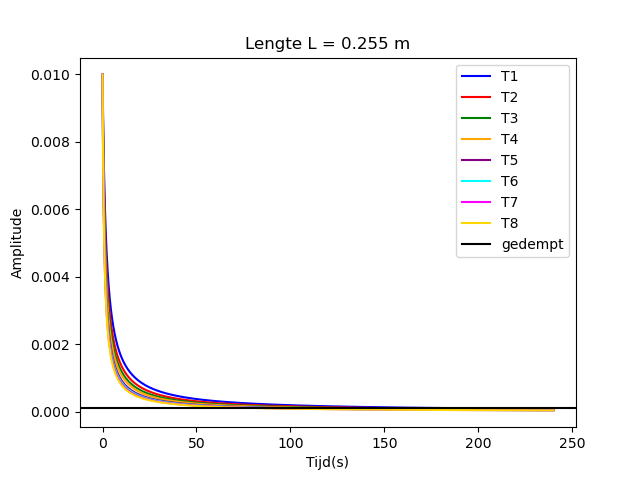

In [2]:
%matplotlib ipympl
import numpy as np 
import matplotlib.pyplot as plt
C_w =1.2
rho = 1.204
D=0.001
mu= 0.015
n=1
m1= 1.0467
m2 = 1.0436
T1 = 9.81*4*m1
T2 = 9.81*6*m1
T3 = 9.81*8*m1
T4 = 9.81*10*m1
T5 = T4 +9.81*4*m2
T6 = T4 +9.81*6*m2
T7 = T4 +9.81*8*m2
T8 = T4 +9.81*10*m2
U_0=0.01
def plot_demping(L):
    alpha1 = ((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T1/mu)
    alpha2 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T2/mu)
    alpha3 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T3/mu)
    alpha4 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T4/mu)
    alpha5 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T5/mu)
    alpha6 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T6/mu)
    alpha7 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T7/mu)
    alpha8 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T8/mu)
    
    t= np.array(np.linspace(0,240,20000))
    C_d1= np.array(1/((alpha1*U_0*t)+1))
    C_d2 = np.array(1/((alpha2*U_0*t)+1))
    C_d3= np.array(1/((alpha3*U_0*t)+1))
    C_d4= np.array(1/((alpha4*U_0*t)+1))
    C_d5= np.array(1/((alpha5*U_0*t)+1))
    C_d6= np.array(1/((alpha6*U_0*t)+1))
    C_d7= np.array(1/((alpha7*U_0*t)+1))
    C_d8= np.array(1/((alpha8*U_0*t)+1))
    plt.figure()

    def Amplitude1(C_d1,U_0):
        U1=U_0*C_d1
        return U1

    plt.plot(t,Amplitude1(C_d1,U_0),color="blue", label="T1")

    def Amplitude2(C_d2,U_0):
        U2=U_0*C_d2
        return U2

    plt.plot(t,Amplitude2(C_d2,U_0),color="red",label="T2")

    def Amplitude3(C_d3,U_0):
        U3=U_0*C_d3
        return U3

    plt.plot(t,Amplitude3(C_d3,U_0),color="green",label="T3")

    def Amplitude4(C_d4,U_0):
        U4=U_0*C_d4
        return U4

    plt.plot(t,Amplitude4(C_d4,U_0),color="orange",label="T4")

    def Amplitude5(C_d5,U_0):
        U5=U_0*C_d5
        return U5

    plt.plot(t,Amplitude5(C_d5,U_0),color="purple",label="T5")

    def Amplitude6(C_d6,U_0):
        U6=U_0*C_d6
        return U6

    plt.plot(t,Amplitude6(C_d6,U_0),color="cyan",label="T6")

    def Amplitude7(C_d7,U_0):
        U7=U_0*C_d7
        return U7

    plt.plot(t,Amplitude7(C_d7,U_0),color="magenta",label="T7")

    def Amplitude8(C_d8,U_0):
        U8=U_0*C_d8
        return U8

    plt.plot(t,Amplitude8(C_d8,U_0),color="gold",label="T8")

    plt.axhline(0.01*U_0,color='0',label="gedempt")
    plt.xlabel("Tijd(s)")
    plt.ylabel("Amplitude")
    plt.title(f"Lengte L = {L} m")
    plt.legend()
    plt.savefig("Amplitude.pdf", bbox_inches="tight")
    plt.show()
L = [0.315, 0.300, 0.285,0.27,0.255]
plot_demping(0.315)
plot_demping(0.300)
plot_demping(0.285)
plot_demping(0.27)
plot_demping(0.255)

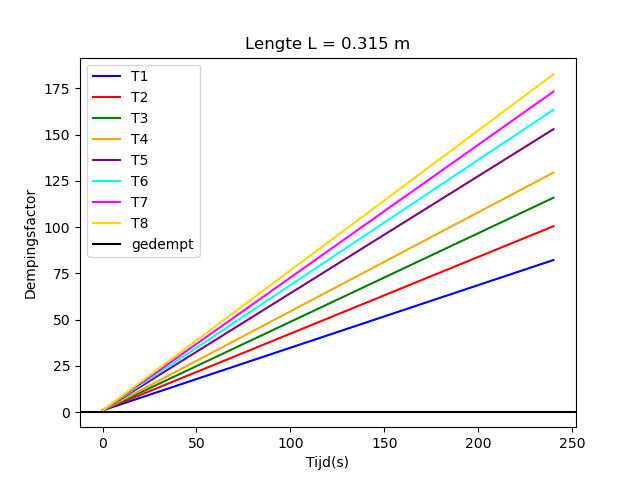

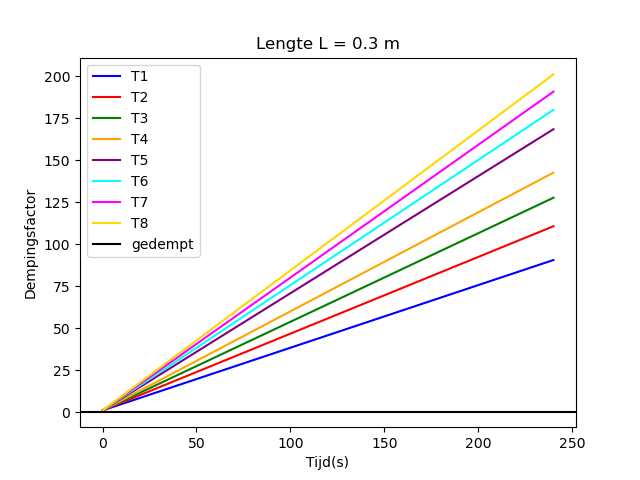

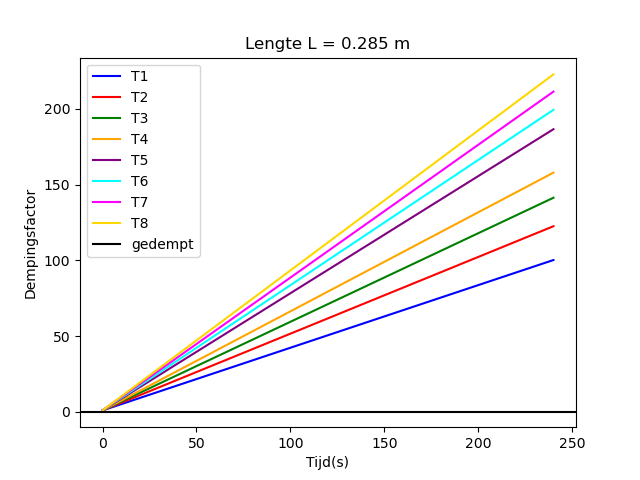

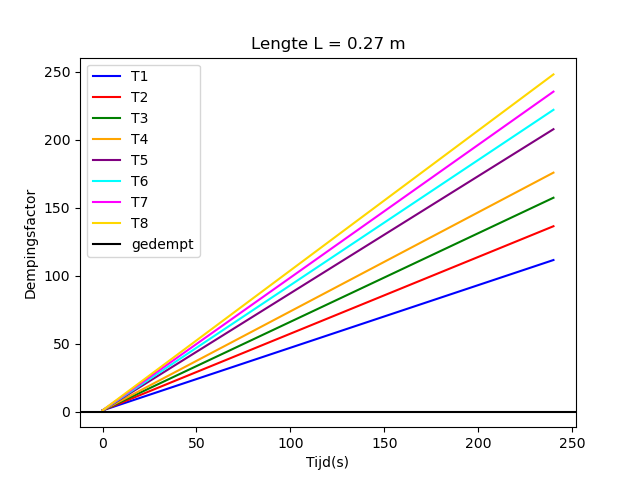

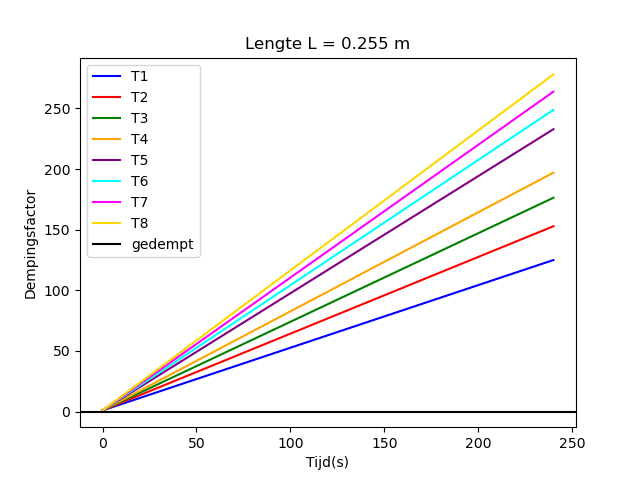

In [3]:
def plot_dempingfactor(L):
    alpha1 = ((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T1/mu)
    alpha2 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T2/mu)
    alpha3 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T3/mu)
    alpha4 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T4/mu)
    alpha5 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T5/mu)
    alpha6 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T6/mu)
    alpha7 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T7/mu)
    alpha8 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T8/mu)
    
    t= np.array(np.linspace(0,240,20000))
    C_d1= np.array(1/((alpha1*U_0*t)+1))
    C_d2 = np.array(1/((alpha2*U_0*t)+1))
    C_d3= np.array(1/((alpha3*U_0*t)+1))
    C_d4= np.array(1/((alpha4*U_0*t)+1))
    C_d5= np.array(1/((alpha5*U_0*t)+1))
    C_d6= np.array(1/((alpha6*U_0*t)+1))
    C_d7= np.array(1/((alpha7*U_0*t)+1))
    C_d8= np.array(1/((alpha8*U_0*t)+1))
    plt.figure()

    def Amplitude1demp(C_d1):
        U1=1/C_d1
        return U1

    plt.plot(t,Amplitude1demp(C_d1),color="blue", label="T1")

    def Amplitude2demp(C_d2):
        U2=1/C_d2
        return U2

    plt.plot(t,Amplitude2demp(C_d2),color="red",label="T2")

    def Amplitude3demp(C_d3):
        U3=1/C_d3
        return U3

    plt.plot(t,Amplitude3demp(C_d3),color="green",label="T3")

    def Amplitude4demp(C_d4):
        U4=1/C_d4
        return U4

    plt.plot(t,Amplitude4demp(C_d4),color="orange",label="T4")

    def Amplitude5demp(C_d5):
        U5=1/C_d5
        return U5

    plt.plot(t,Amplitude5demp(C_d5),color="purple",label="T5")

    def Amplitude6demp(C_d6):
        U6=1/C_d6
        return U6

    plt.plot(t,Amplitude6demp(C_d6),color="cyan",label="T6")

    def Amplitude7demp(C_d7):
        U7=1/C_d7
        return U7

    plt.plot(t,Amplitude7demp(C_d7),color="magenta",label="T7")

    def Amplitude8demp(C_d8):
        U8=1/C_d8
        return U8

    plt.plot(t,Amplitude8demp(C_d8),color="gold",label="T8")

    plt.axhline(0.01*U_0,color='0',label="gedempt")
    plt.xlabel("Tijd(s)")
    plt.ylabel("Dempingsfactor")
    plt.title(f"Lengte L = {L} m")
    plt.legend()
    plt.savefig("Dempingsfactor.pdf", bbox_inches="tight")
    plt.show()
plot_dempingfactor(0.315)
plot_dempingfactor(0.300)
plot_dempingfactor(0.285)
plot_dempingfactor(0.27)
plot_dempingfactor(0.255)

Oscillation simulation.

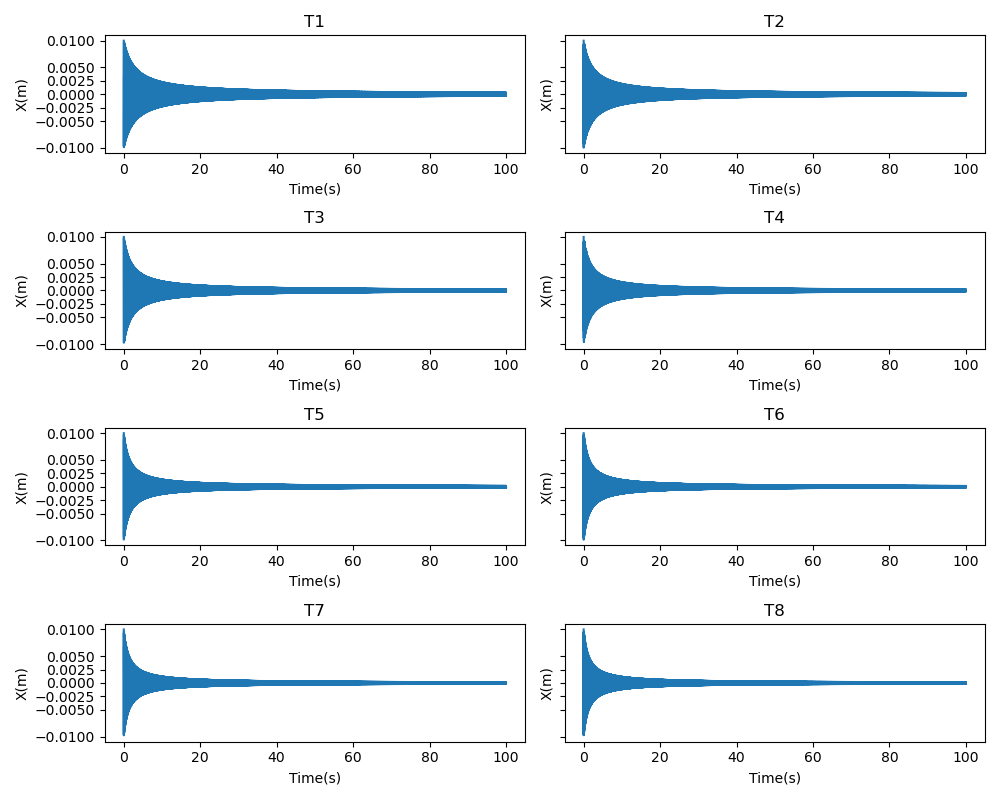

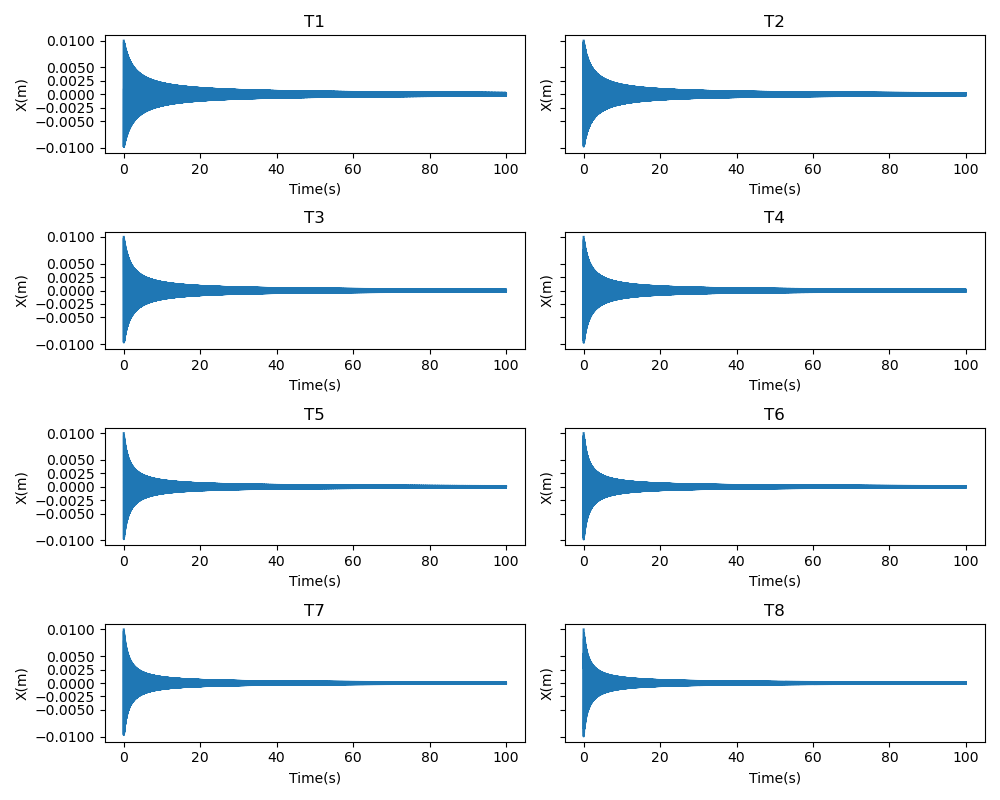

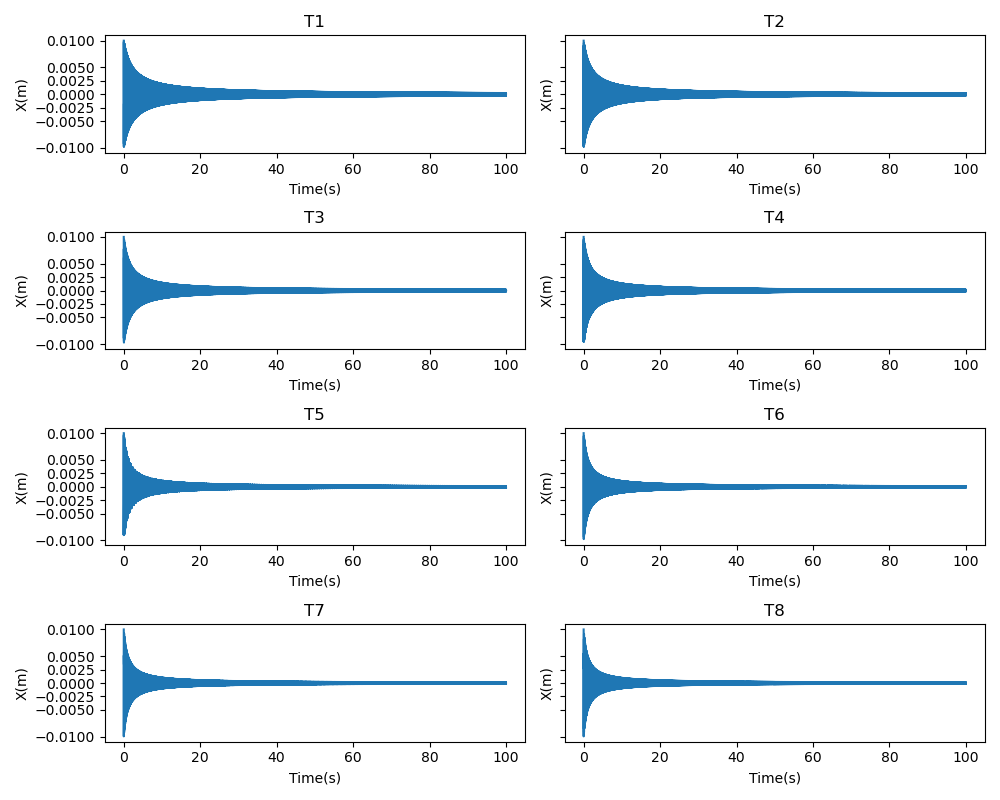

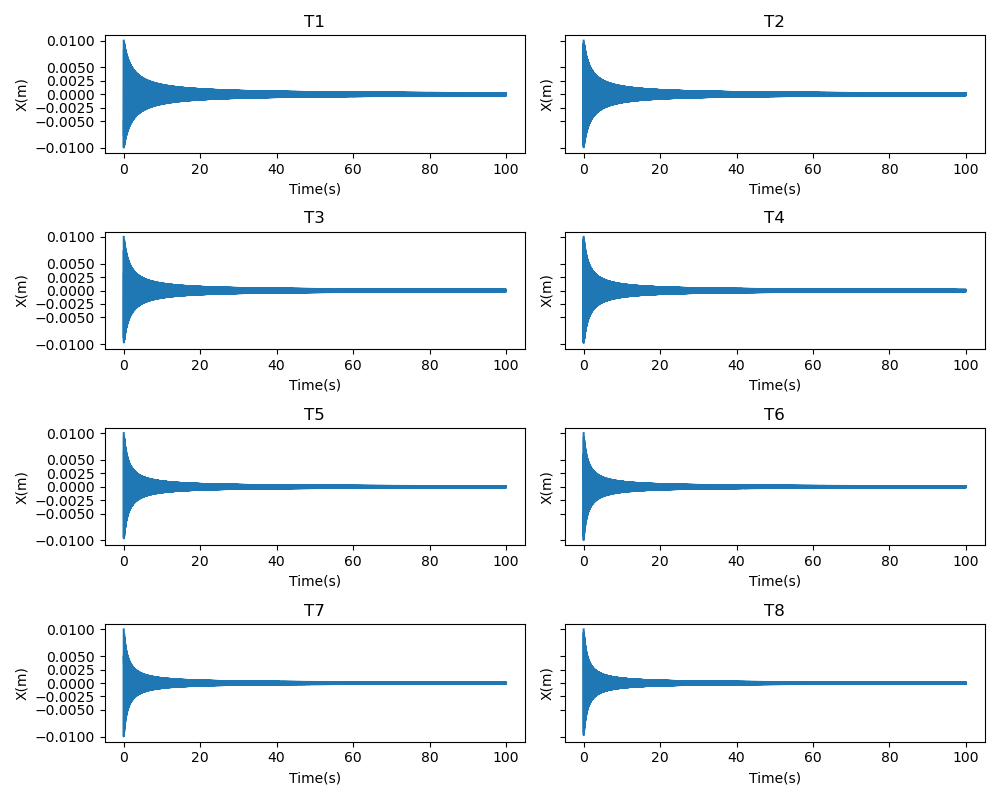

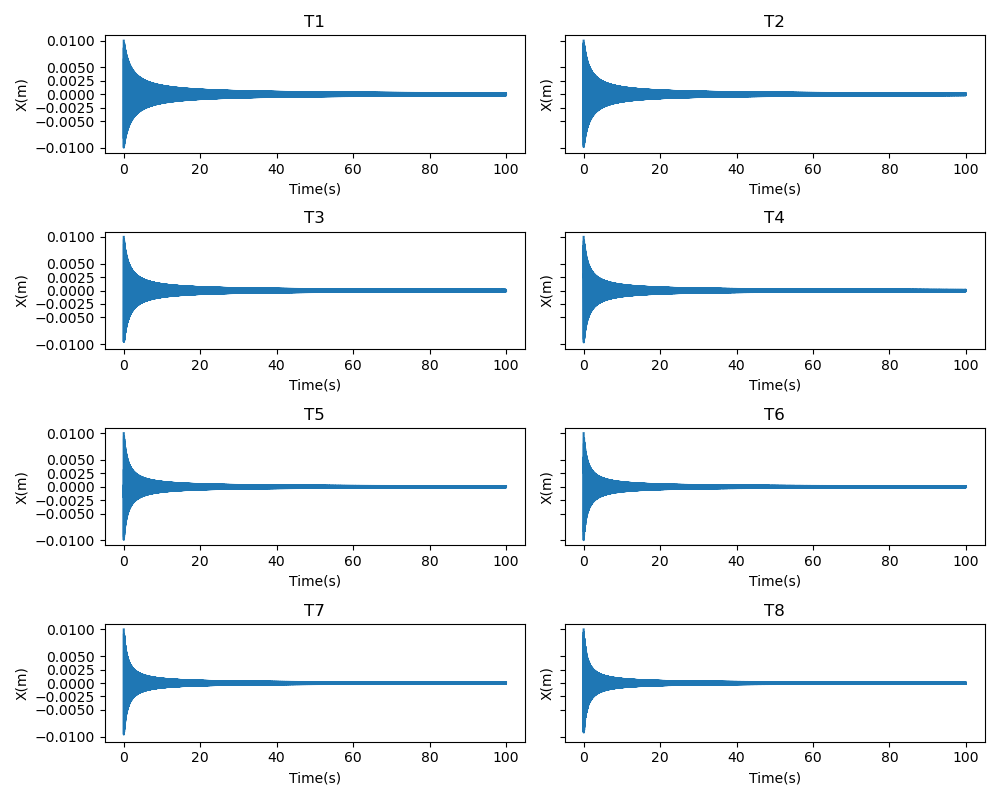

In [4]:
plt.close('all')

def Oscillation(U_0,t,L):
    alpha1 = ((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T1/mu)
    alpha2 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T2/mu)
    alpha3 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T3/mu)
    alpha4 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T4/mu)
    alpha5 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T5/mu)
    alpha6 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T6/mu)
    alpha7 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T7/mu)
    alpha8 =((2*C_w*rho*D*n)/(3*mu*L**2))*np.sqrt(T8/mu)
    C_d1 = np.array(1/((alpha1*U_0*t)+1))
    C_d2 = np.array(1/((alpha2*U_0*t)+1))
    C_d3= np.array(1/((alpha3*U_0*t)+1))
    C_d4= np.array(1/((alpha4*U_0*t)+1))
    C_d5= np.array(1/((alpha5*U_0*t)+1))
    C_d6= np.array(1/((alpha6*U_0*t)+1))
    C_d7= np.array(1/((alpha7*U_0*t)+1))
    C_d8= np.array(1/((alpha8*U_0*t)+1))
    omega1 = (n*np.pi/L)*np.sqrt(T1/mu)
    omega2 = (n*np.pi/L)*np.sqrt(T2/mu)
    omega3 = (n*np.pi/L)*np.sqrt(T3/mu)
    omega4 = (n*np.pi/L)*np.sqrt(T4/mu)
    omega5 = (n*np.pi/L)*np.sqrt(T5/mu)
    omega6 = (n*np.pi/L)*np.sqrt(T6/mu)
    omega7 = (n*np.pi/L)*np.sqrt(T7/mu)
    omega8 = (n*np.pi/L)*np.sqrt(T8/mu)
    x1 = U_0*C_d1*np.cos(omega1*t)
    x2 = U_0*C_d2*np.cos(omega2*t)
    x3 = U_0*C_d3*np.cos(omega3*t)
    x4 = U_0*C_d4*np.cos(omega4*t)
    x5 = U_0*C_d5*np.cos(omega5*t)
    x6 = U_0*C_d6*np.cos(omega6*t)
    x7 = U_0*C_d7*np.cos(omega7*t)
    x8 = U_0*C_d8*np.cos(omega8*t)
    fig, ax = plt.subplots(4, 2, figsize=(10, 8),sharey=True)
    ax[0,0].plot(t,x1)
    ax[0,0].set_xlabel("Time(s)")
    ax[0,0].set_ylabel("X(m)")
    ax[0,0].set_title("T1")
    
    ax[0,1].plot(t,x2)
    ax[0,1].set_xlabel("Time(s)")
    ax[0,1].set_ylabel("X(m)")
    ax[0,1].set_title("T2")
    
    
    ax[1,0].plot(t,x3)
    ax[1,0].set_xlabel("Time(s)")
    ax[1,0].set_ylabel("X(m)")
    ax[1,0].set_title("T3")
    
    
    ax[1,1].plot(t,x4)
    ax[1,1].set_xlabel("Time(s)")
    ax[1,1].set_ylabel("X(m)")
    ax[1,1].set_title("T4")
    
    
    ax[2,0].plot(t,x5)
    ax[2,0].set_xlabel("Time(s)")
    ax[2,0].set_ylabel("X(m)")
    ax[2,0].set_title("T5")
    
    
    ax[2,1].plot(t,x6)
    ax[2,1].set_xlabel("Time(s)")
    ax[2,1].set_ylabel("X(m)")
    ax[2,1].set_title("T6")
    
    
    ax[3,0].plot(t,x7)
    ax[3,0].set_xlabel("Time(s)")
    ax[3,0].set_ylabel("X(m)")
    ax[3,0].set_title("T7")
    
    
    ax[3,1].plot(t,x8)
    ax[3,1].set_xlabel("Time(s)")
    ax[3,1].set_ylabel("X(m)")
    ax[3,1].set_title("T8")
    for row in ax:
        for a in row:
            a.set_yticks([-0.01, -0.005, -0.0025, 0, 0.0025, 0.005, 0.01])
    plt.tight_layout()
    plt.savefig("oscillations.pdf", bbox_inches="tight")
    plt.show()
t_o=np.linspace(0,100,40000)
Oscillation(U_0,t_o,0.315)
Oscillation(U_0,t_o,0.3)
Oscillation(U_0,t_o,0.285)
Oscillation(U_0,t_o,0.27)
Oscillation(U_0,t_o,0.255)